# Steps

 0. Preprocess + EDA + Feature Selection
 1. Extract input and output cols
 2. Scale the values
 3. Train test split|
 4. Train the model
 5. Evaluate the model/model selection
 6. Deploy the model

In [1]:
import numpy as np 
import pandas as pd


In [2]:
df=pd.read_csv('placement.csv')

In [4]:
df.head()


,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [6]:
df=df.iloc[:,1:]

In [9]:
df.isnull().sum()

cgpa         0
iq           0
placement    0
dtype: int64

In [10]:
import matplotlib.pyplot as plt


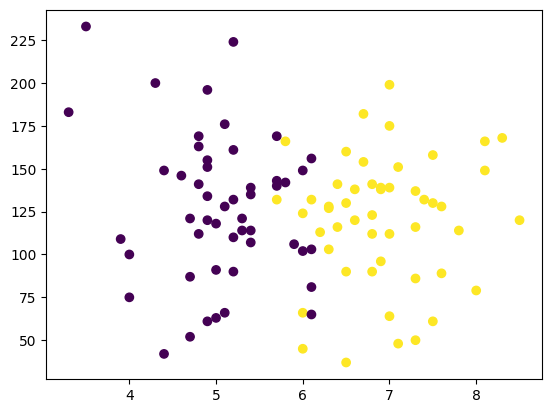

In [12]:
plt.scatter(df['cgpa'],df['iq'],c=df['placement'])

In [17]:
X=df.iloc[:,0:2]
y=df.iloc[:,-1]

In [19]:
y

0     1
1     0
2     0
3     1
4     0
     ..
95    0
96    0
97    1
98    1
99    1
Name: placement, Length: 100, dtype: int64

In [20]:
# 3. Train test split
from sklearn.model_selection import train_test_split

In [22]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.1)

In [25]:
X_train

,cgpa,iq
22,4.9,120.0
74,6.7,154.0
31,3.9,109.0
29,7.0,112.0
81,5.4,107.0
...,...,...
11,6.9,138.0
4,5.8,142.0
42,7.6,89.0
37,8.1,149.0


In [26]:
y_train

22    0
74    1
31    0
29    1
81    0
     ..
11    1
4     0
42    1
37    1
9     0
Name: placement, Length: 90, dtype: int64

In [27]:
X_test

,cgpa,iq
78,6.1,81.0
83,7.5,130.0
44,7.5,61.0
80,4.9,196.0
89,4.9,151.0
95,4.3,200.0
34,4.8,163.0
75,4.8,169.0
79,6.5,90.0
39,4.6,146.0


In [28]:
y_test

78    0
83    1
44    1
80    0
89    0
95    0
34    0
75    0
79    1
39    0
Name: placement, dtype: int64

In [32]:
from sklearn.preprocessing import StandardScaler

In [33]:
scaler=StandardScaler()

In [34]:
X_train=scaler.fit_transform(X_train)

In [35]:
X_train

array([[-1.00691072, -0.04908505],
       [ 0.58917085,  0.82927897],
       [-1.89362271, -0.33326164],
       [ 0.85518445, -0.25575893],
       [-0.56355473, -0.38493011],
       [ 0.67784205, -0.82411212],
       [ 0.76651325,  0.44176543],
       [ 0.05714366, -1.46996801],
       [-0.12019874, -0.41076435],
       [-1.09558192,  0.4934339 ],
       [ 0.23448606, -0.48826706],
       [ 0.85518445,  1.99181958],
       [-0.74089713,  0.26092578],
       [ 2.00791003,  1.19095827],
       [ 1.12119805, -0.92744906],
       [ 0.32315726,  0.4934339 ],
       [-0.03152754, -1.98665273],
       [-1.80495151, -0.56576976],
       [-1.18425312, -1.80581308],
       [ 1.12119805, -1.85748155],
       [-0.74089713,  2.63767547],
       [-0.56355473,  0.33842849],
       [ 0.76651325, -0.66910671],
       [-1.00691072,  0.8551132 ],
       [-0.03152754,  0.0542519 ],
       [ 0.05714366,  0.88094744],
       [ 1.12119805, -0.15242199],
       [-0.74089713, -0.30742741],
       [ 0.58917085,

In [36]:
X_test=scaler.transform(X_test)

In [37]:
X_test

array([[ 0.05714366, -1.05662024],
       [ 1.29854044,  0.20925731],
       [ 1.29854044, -1.57330496],
       [-1.00691072,  1.91431687],
       [-1.00691072,  0.75177626],
       [-1.53893792,  2.01765381],
       [-1.09558192,  1.06178709],
       [-1.09558192,  1.2167925 ],
       [ 0.41182846, -0.82411212],
       [-1.27292432,  0.62260508]])

In [38]:
from sklearn.linear_model import LogisticRegression

In [39]:
clf=LogisticRegression()

In [40]:
#model Training
clf.fit(X_train,y_train)

LogisticRegression()

In [43]:
# Evalute the model 
y_pred=clf.predict(X_test)

In [44]:
y_test

78    0
83    1
44    1
80    0
89    0
95    0
34    0
75    0
79    1
39    0
Name: placement, dtype: int64

In [46]:
from sklearn.metrics import accuracy_score

In [48]:
accuracy_score(y_test,y_pred)

0.9

In [57]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

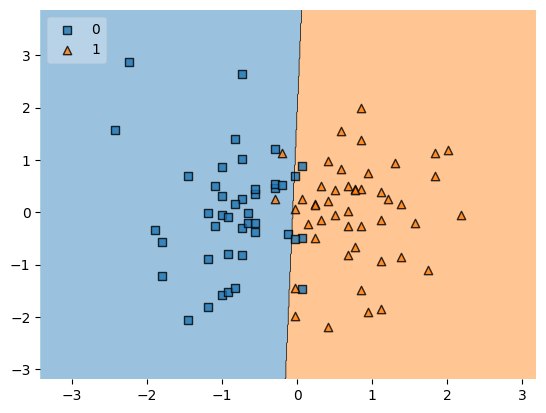

In [59]:
plot_decision_regions(X_train,y_train.values,clf=clf,legend=2)

In [61]:
import pickle

In [62]:
pickle.dump(clf,open('model.pkl','wb'))